# Per-line opcode cost analysis

`tealtools.cost_analysis` gives every line a worst-case cumulative
budget cost — and, via `per_line_cost_paths`, the full list of every
cumulative cost at which the line is reachable, one per execution
path / loop iteration.

Pipeline:

1. **Control tree** (`tealtools.control_tree`): structural analysis
   lifts the CFG into a typed region tree — `Block`, `Sequence`,
   `If`, `IfElse`, `Switch`, `Loop`, `Improper`. Loops are processed
   inner-first via SCCs (`tealtools.loops`).
2. **Cost fold**: a recursive function over that tree. Each region
   kind has a closed-form rule for cum/ic propagation; loops use a
   static body summary + the AVM budget rule for `max_iters`.
3. Output: per-line max cum, or per-line cum **list** (one entry
   per distinct iteration / path that reaches the line).

Reported cums are always sound upper bounds on actual max cost — no
false negatives for budget-exhaustion findings.

In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault("CODEQL", "/home/argi/tools/codeql/codeql")
HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent.parent))

from tealtools.ssa import SSAProgram
from tealtools.cost_analysis import (
    render, to_dict, per_line_costs, per_line_cost_paths,
    program_budget_ceiling, path_ceiling, inner_txn_count,
    HARD_BUDGET_LIMIT, TXN_BUDGET, ASSUMED_GROUP_SIZE,
    MAX_INNER_TXNS, MAX_CUMS_PER_LINE,
)
from tealtools.control_tree import (
    build_control_tree, pretty, to_dot, to_mermaid,
    BlockR, SequenceR, IfR, IfElseR, SwitchR, LoopR, ImproperR,
)

FIXTURES = HERE.parent.parent / "tests" / "tealtools" / "cost"


## The control tree

Structural analysis matches CFG patterns (sequence, if/else, switch,
loop) and collapses them bottom-up. Anything that won't reduce
becomes an `Improper` region.

`pretty(tree)` shows the decomposition as indented text. `to_dot`
gives Graphviz; `to_mermaid` works inline in markdown.

In [2]:
for case in ("linear", "branching", "with_loop"):
    p = SSAProgram(str(FIXTURES / case / "db"))
    print(f"=== {case} ===")
    print(pretty(build_control_tree(p)))
    print()


=== linear ===
block lines=[5, 6, 7, 8, 9, 10] ops=[pushbytes,sha256,pushint,+,pushint,return]



=== branching ===
sequence
  ifelse
    block lines=[5, 6, 7] ops=[txna,btoi,bnz]
    then:
      block lines=[9, 10] ops=[pushbytes,b]
    else:
      block lines=[13, 14, 15] ops=[pushbytes,keccak256,pop]
  block lines=[18, 19] ops=[pushint,return]



=== with_loop ===
sequence
  block lines=[5] ops=[pushint]
  loop (1 bbs)
    block lines=[7, 8, 9, 10, 11, 12, 13] ops=[pushint,+,dup,txna,btoi,<,bnz]
  block lines=[15] ops=[return]



## Visualising the tree

Two DOT renderings are available:

- `to_dot(tree, nested=True)` — nested clusters, sequences carry
  dashed-arrow ordering inside each cluster. Best for *seeing* the
  decomposition.
- `to_dot(tree, nested=False)` — parent-child tree where every
  region is a node and edges are labelled by role
  (`cond` / `then` / `else` / `body` / `case N`).

`to_mermaid(tree)` returns a Mermaid `flowchart TD` source — handy
to inline in markdown where Graphviz isn't available.

In [3]:
# Render `with_loop`'s control tree to SVG using the dot binary.
import shutil, subprocess, tempfile, base64
from IPython.display import SVG, display, HTML

def render_svg(dot_source):
    if not shutil.which("dot"):
        print("(graphviz `dot` binary not available — skipping render)")
        return None
    with tempfile.NamedTemporaryFile(suffix=".dot", delete=False) as f:
        f.write(dot_source.encode())
        path = f.name
    out = subprocess.check_output(["dot", "-Tsvg", path])
    return out.decode()

p_loop = SSAProgram(str(FIXTURES / "with_loop" / "db"))
tree = build_control_tree(p_loop)
svg = render_svg(to_dot(tree, nested=True))
if svg:
    display(SVG(svg))
else:
    print(to_dot(tree, nested=True))


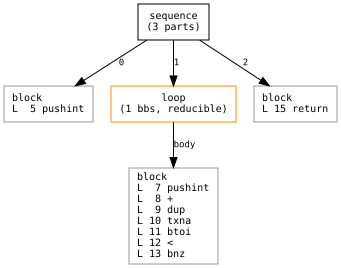

In [4]:
# Parent-child tree variant for the same fixture.
svg = render_svg(to_dot(tree, nested=False))
if svg:
    display(SVG(svg))
else:
    print(to_dot(tree, nested=False))


## Cost numbers via the structural fold

`per_line_costs(prog)` runs the fold and returns per-line max cum;
`render(prog)` is the human-readable text table.

In [5]:
for case in ("linear", "branching", "with_loop"):
    p = SSAProgram(str(FIXTURES / case / "db"))
    print(f"--- {case} ---")
    print(render(p))
    print()


--- linear ---
prog.teal:L5    pushbytes  op_cost=1     cum=1
prog.teal:L6    sha256     op_cost=35    cum=36
prog.teal:L7    pushint    op_cost=1     cum=37
prog.teal:L8    +          op_cost=1     cum=38
prog.teal:L9    pushint    op_cost=1     cum=39
prog.teal:L10   return     op_cost=1     cum=40



--- branching ---
prog.teal:L5    txna       op_cost=1     cum=1
prog.teal:L6    btoi       op_cost=1     cum=2
prog.teal:L7    bnz        op_cost=1     cum=3
prog.teal:L9    pushbytes  op_cost=1     cum=4
prog.teal:L10   b          op_cost=1     cum=5
prog.teal:L13   pushbytes  op_cost=1     cum=4
prog.teal:L14   keccak256  op_cost=130   cum=134
prog.teal:L15   pop        op_cost=1     cum=135
prog.teal:L18   pushint    op_cost=1     cum=136
prog.teal:L19   return     op_cost=1     cum=137



--- with_loop ---
prog.teal:L5    pushint  op_cost=1     cum=1
prog.teal:L7    pushint  op_cost=1     cum=2795
prog.teal:L8    +        op_cost=1     cum=2796
prog.teal:L9    dup      op_cost=1     cum=2797
prog.teal:L10   txna     op_cost=1     cum=2798
prog.teal:L11   btoi     op_cost=1     cum=2799
prog.teal:L12   <        op_cost=1     cum=2800
prog.teal:L13   bnz      op_cost=1     cum=2794
prog.teal:L15   return   op_cost=1     cum=2795



## Every cumulative cost per line (`per_line_cost_paths`)

For each line, the full list of distinct cums at which it can
execute — including one per loop iteration, and one per "exited
after k iters" value at post-loop lines.

For `with_loop`:

- L7–L12 (loop body) each get **400 cums** = one per iter k ∈ [1, 400].
- L13 (the bnz) gets **399** — iter 400 would put it at cum 2801 > 2800
  ceiling, so the AVM halts before reaching it.
- L15 (post-loop return) gets **400** — one per "exited after k iters".

In [6]:
p = SSAProgram(str(FIXTURES / "with_loop" / "db"))
for key, (op, oc, cums) in sorted(per_line_cost_paths(p).items()):
    if len(cums) <= 6:
        print(f"  L{key[1]:<3} {op:<8} ({len(cums)} cum): {cums}")
    else:
        print(f"  L{key[1]:<3} {op:<8} ({len(cums)} cums): "
              f"{cums[:3]} ... {cums[-3:]}  step={cums[1]-cums[0]}")


  L5   pushint  (1 cum): [1]
  L7   pushint  (400 cums): [2, 9, 16] ... [2781, 2788, 2795]  step=7
  L8   +        (400 cums): [3, 10, 17] ... [2782, 2789, 2796]  step=7
  L9   dup      (400 cums): [4, 11, 18] ... [2783, 2790, 2797]  step=7
  L10  txna     (400 cums): [5, 12, 19] ... [2784, 2791, 2798]  step=7
  L11  btoi     (400 cums): [6, 13, 20] ... [2785, 2792, 2799]  step=7
  L12  <        (400 cums): [7, 14, 21] ... [2786, 2793, 2800]  step=7
  L13  bnz      (399 cums): [8, 15, 22] ... [2780, 2787, 2794]  step=7
  L15  return   (400 cums): [2, 9, 16] ... [2781, 2788, 2795]  step=7


## Real contract: xgov

xgov decomposes into a mix of sequences, if/ifelse, loops, and a
handful of `Improper` regions (irreducible sub-graphs). The cost
fold handles all of them in a single pass.

In [7]:
import time

p_xgov = SSAProgram(str(HERE.parent.parent / "tests" / "dbs" / "xgov-db"))
p_xgov.propagate_constants()

t0 = time.perf_counter()
tree = build_control_tree(p_xgov)
dt_tree = (time.perf_counter() - t0) * 1000

counts: dict[str, int] = {}
for r in tree.walk():
    counts[r.kind] = counts.get(r.kind, 0) + 1
print(f"build_control_tree: {dt_tree:.0f}ms")
print("region kinds:")
for k, v in sorted(counts.items()):
    print(f"  {k}: {v}")
print()

t0 = time.perf_counter()
d = to_dict(p_xgov)
dt_cost = (time.perf_counter() - t0) * 1000
print(f"to_dict (max-cum):     {dt_cost:.0f}ms")
print(f"  budget_ceiling          : {d['budget_ceiling']}")
print(f"  max_observed_cumulative : {d['max_observed_cumulative']}")
print(f"  lines over ceiling      : "
      f"{sum(1 for e in d['entries'] if e['cumulative'] > d['budget_ceiling'])}")


build_control_tree: 35ms
region kinds:
  block: 161
  if: 3
  ifelse: 8
  improper: 5
  loop: 6
  sequence: 30

to_dict (max-cum):     62ms
  budget_ceiling          : 182000
  max_observed_cumulative : 170586
  lines over ceiling      : 0


## JSON form

Default `to_dict(prog)` returns per-line max. With `paths=True` each
entry carries the full sorted cums list — every distinct value at
which the line is reachable, including one per loop iteration.

In [8]:
d = to_dict(p_loop, paths=True)
print(f"budget_ceiling         : {d['budget_ceiling']}")
print(f"max_observed_cumulative: {d['max_observed_cumulative']}")
print()
for e in d["entries"]:
    if e["line"] == 15:
        cums = e["cumulatives"]
        print(f"L{e['line']} {e['op']} op_cost={e['op_cost']}")
        print(f"  {len(cums)} cumulatives: first={cums[:3]}, last={cums[-3:]}")
        break


budget_ceiling         : 2800
max_observed_cumulative: 2800

L15 return op_cost=1
  400 cumulatives: first=[2, 9, 16], last=[2781, 2788, 2795]
